## TimeSeries Assignment_17

In [68]:
import pandas as pd
import matplotlib.pyplot as plt

### Part 1: Data Preparation and Exploration
#### 1.	Data Loading: Load the exchange_rate.csv dataset and parse the date column appropriately.


In [69]:
#load Dataset
df=pd.read_csv('exchange_rate.csv')
#display data
df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [70]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df.set_index('date', inplace=True)

In [71]:
#shape
df.shape

(7588, 1)

In [72]:
#data information
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7588 entries, 1990-01-01 to 2010-10-10
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6 KB


In [73]:
#check missing value
df.isnull().sum()

Ex_rate    0
dtype: int64

#### 2.	Initial Exploration: Plot the time series for currency to understand their trends, seasonality, and any anomalies.

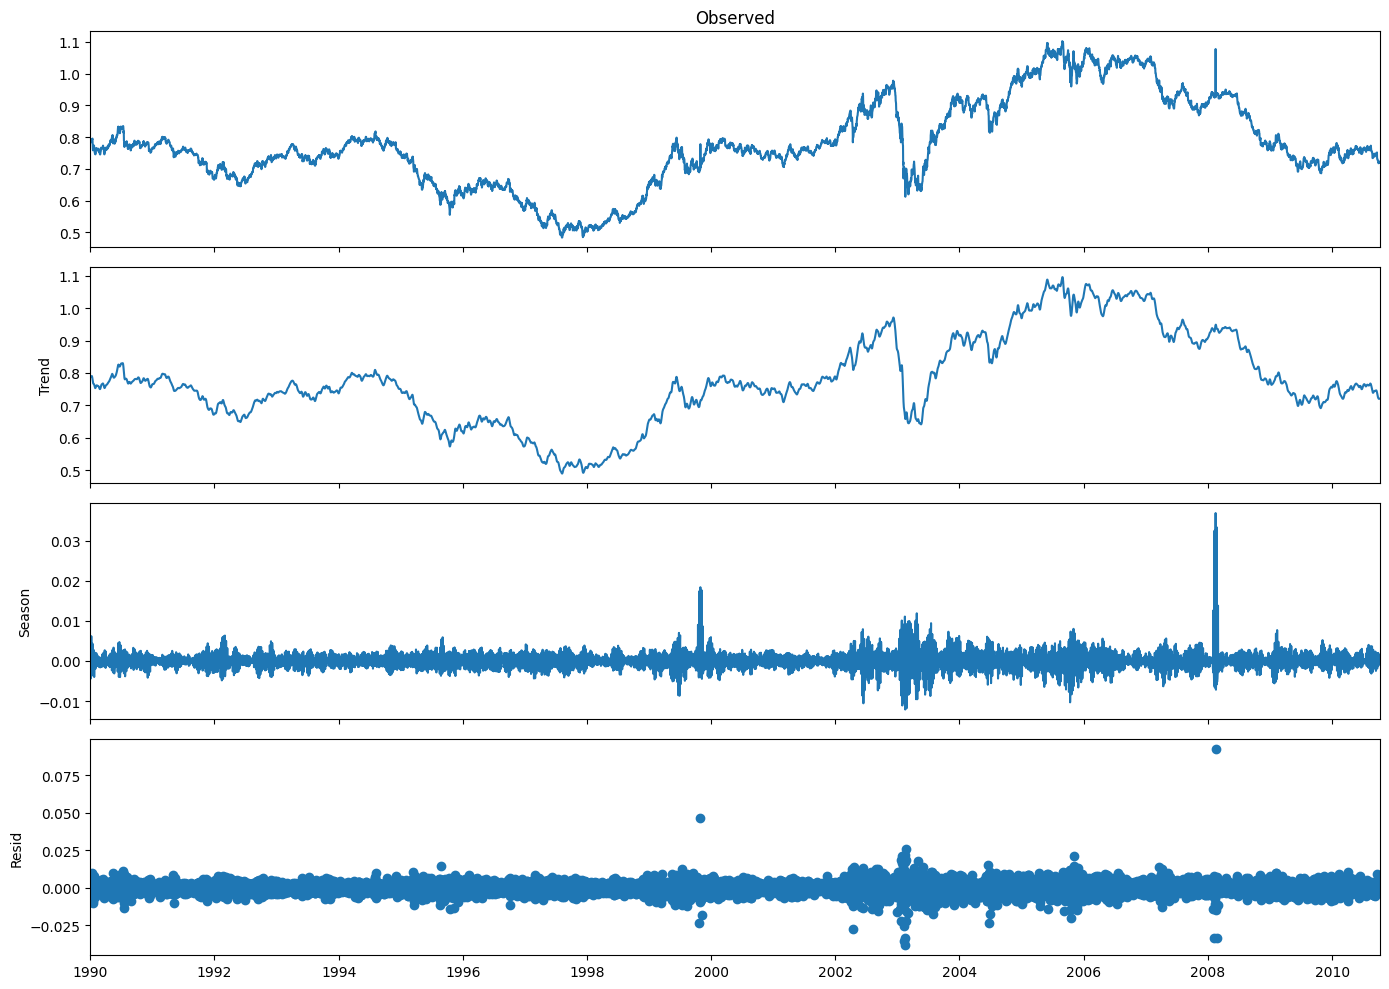

In [74]:
from statsmodels.tsa.seasonal import STL
res = STL(df).fit()

fig = res.plot()
fig.set_size_inches(14, 10)

plt.tight_layout()
plt.show()

#### 3.	Data Preprocessing: Handle any missing values or anomalies identified during the exploration phase.

In [75]:
# Check missing values
print(df.isnull().sum())

Ex_rate    0
dtype: int64


In [76]:
import numpy as np

data = df.iloc[:,0]

# Calculate Z-score
z_scores = (data - data.mean()) / data.std()

# Find anomalies (threshold = 3)
anomalies = data[np.abs(z_scores) > 3]

print(anomalies)

Series([], Name: Ex_rate, dtype: float64)


no anomalies found

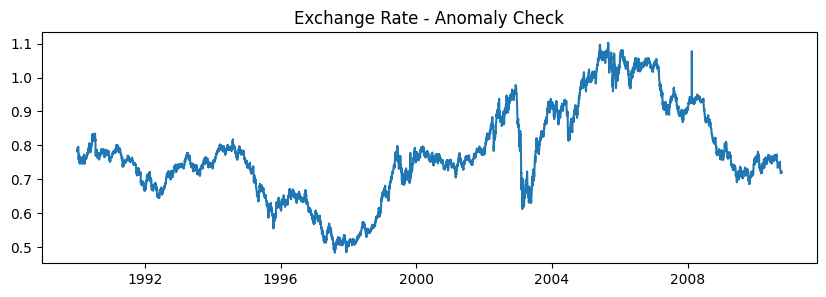

In [77]:
plt.figure(figsize=(10,3))
plt.plot(data)
plt.title("Exchange Rate - Anomaly Check")
plt.show()

### Part 2: Model Building - ARIMA
#### 1.	Parameter Selection for ARIMA: Utilize ACF and PACF plots to estimate initial parameters (p, d, q) for the ARIMA model for one or more currency time series.

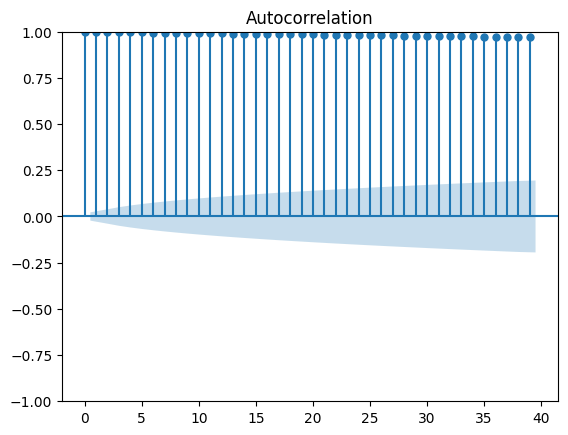

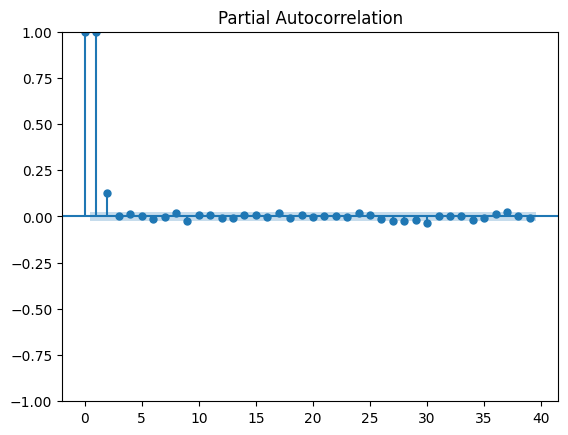

In [78]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF
plot_acf(df.iloc[:,0])
plot_pacf(df.iloc[:,0])
plt.show()

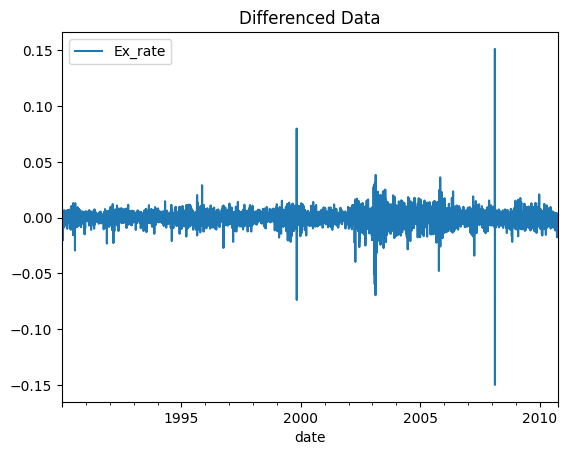

In [79]:
# Differencing
df_diff = df.diff().dropna()

# Plot differenced data
df_diff.plot(title='Differenced Data')
plt.show()

#### 2.	Model Fitting: Fit the ARIMA model with the selected parameters to the preprocessed time series.

In [96]:
from statsmodels.tsa.arima.model import ARIMA
df = df.asfreq('D')
# Fit ARIMA model
model = ARIMA(df.iloc[:,0], order=(1,1,1))  # (p,d,q)
model_fit = model.fit()

# Print summary
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 1)   Log Likelihood               28054.161
Date:                Wed, 01 Apr 2026   AIC                         -56102.322
Time:                        22:54:36   BIC                         -56081.519
Sample:                    01-01-1990   HQIC                        -56095.182
                         - 10-10-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1268      0.045     -2.797      0.005      -0.216      -0.038
ma.L1         -0.0046      0.045     -0.101      0.920      -0.094       0.085
sigma2      3.596e-05   9.94e-08    361.604      0.0

#### 3.	Diagnostics: Analyze the residuals to ensure there are no patterns that might indicate model inadequacies.

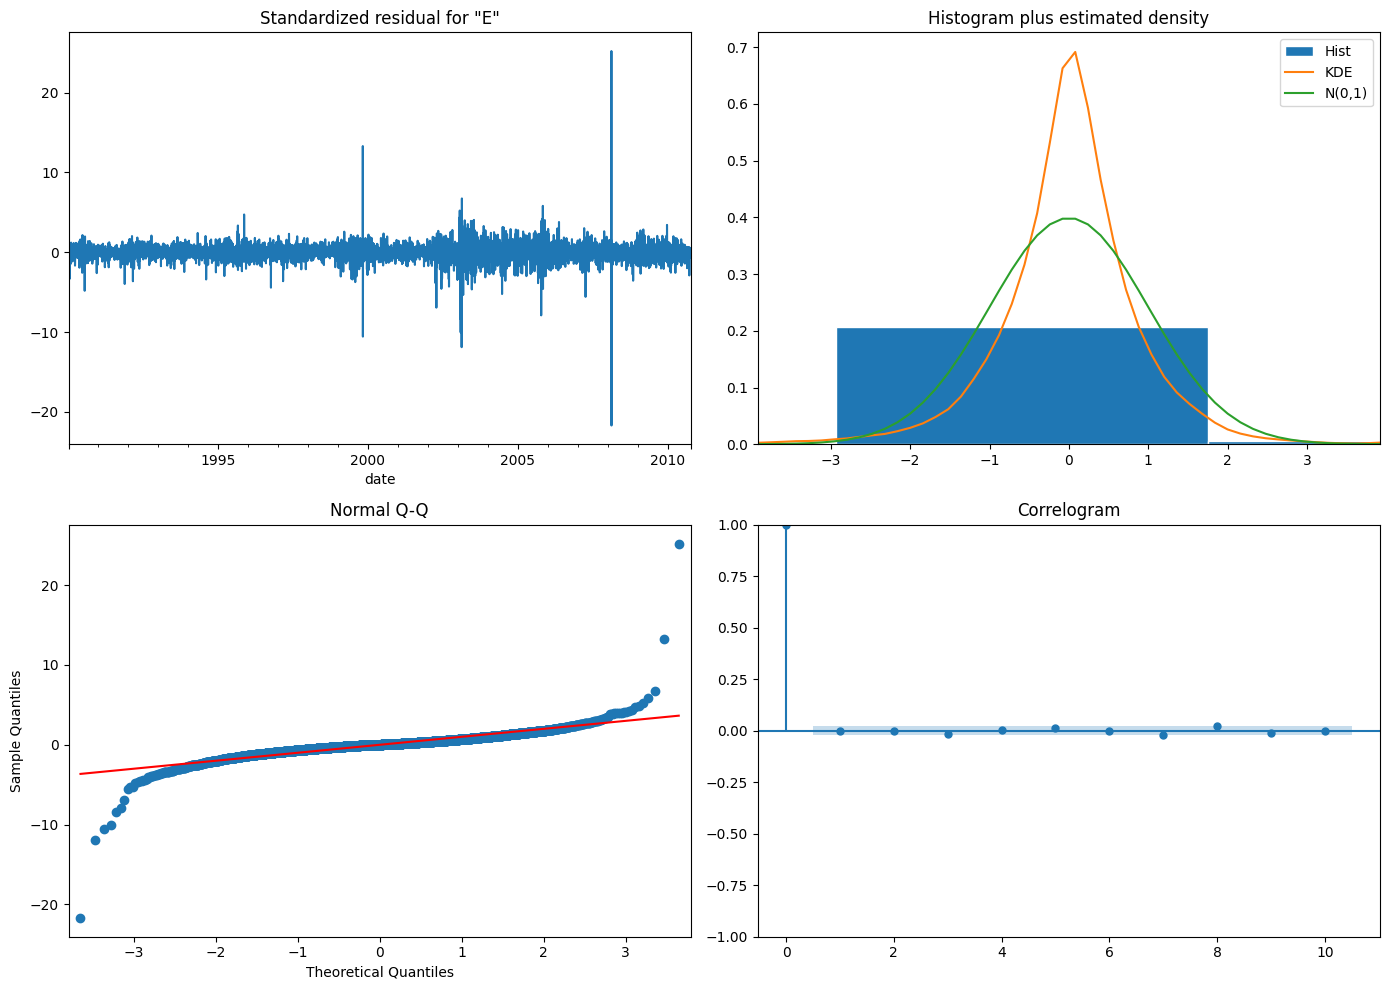

In [97]:
# Generate diagnostic plots
fig = model_fit.plot_diagnostics(figsize=(14, 10))  # increase size

# Adjust layout for better visibility
plt.tight_layout()

plt.show()

#### 4.	Forecasting: Perform out-of-sample forecasting and visualize the predicted values against the actual values.


In [98]:
# Split data into train and test
train = df.iloc[:-20]
test = df.iloc[-20:]

# Fit model on training data
model = ARIMA(train.iloc[:,0], order=(1,1,1))
model_fit = model.fit()

# Forecast
forecast = model_fit.forecast(steps=len(test))
forecast

2010-09-21    0.748429
2010-09-22    0.748495
2010-09-23    0.748487
2010-09-24    0.748488
2010-09-25    0.748488
2010-09-26    0.748488
2010-09-27    0.748488
2010-09-28    0.748488
2010-09-29    0.748488
2010-09-30    0.748488
2010-10-01    0.748488
2010-10-02    0.748488
2010-10-03    0.748488
2010-10-04    0.748488
2010-10-05    0.748488
2010-10-06    0.748488
2010-10-07    0.748488
2010-10-08    0.748488
2010-10-09    0.748488
2010-10-10    0.748488
Freq: D, Name: predicted_mean, dtype: float64

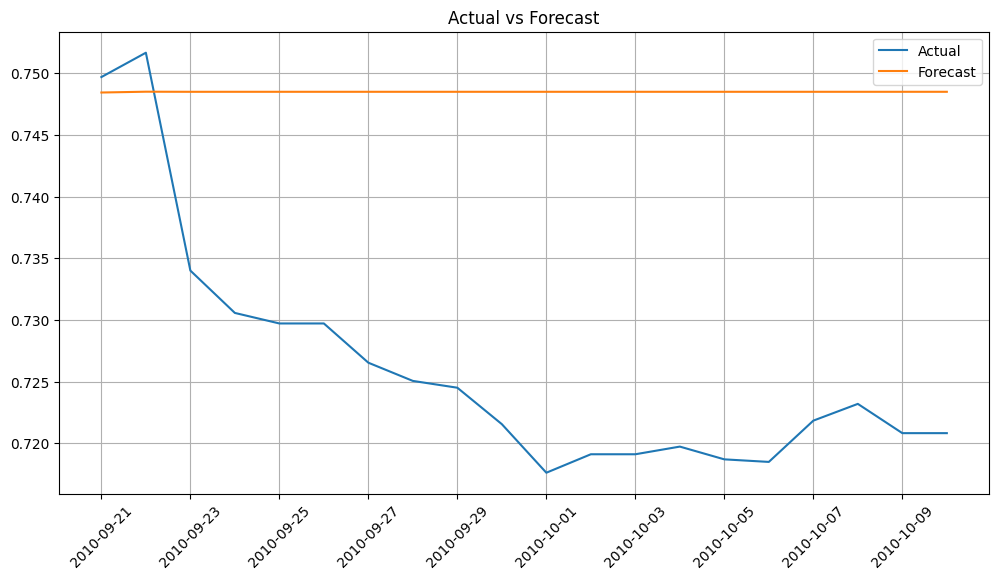

In [99]:
# Plot actual vs forecast
plt.figure(figsize=(12,6))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast, label='Forecast')

plt.legend()
plt.title("Actual vs Forecast")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

### Part 3: Evaluation and Comparison
#### 1.	Compute Error Metrics: Use metrics such as MAE, RMSE, and MAPE to evaluate the forecasts from both models.


In [100]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate metrics
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test.values - forecast.values) / np.where(test.values == 0, 1e-8, test.values))) * 100
# Print results
print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 0.022804213726623824
RMSE: 0.024239977175742836
MAPE: 3.154634708664996


#### 2.	Model Comparison: Discuss the performance, advantages, and limitations of each model based on the observed results and error metrics.

In [101]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Train model
model_es = ExponentialSmoothing(train, trend='add', seasonal=None)
fit_es = model_es.fit()

# Forecast
forecast_es = fit_es.forecast(len(test))

# Metrics
mae_es = mean_absolute_error(test, forecast_es)
rmse_es = np.sqrt(mean_squared_error(test, forecast_es))
mape_es = np.mean(np.abs((test.values - forecast_es.values) / np.where(test.values == 0, 1e-8, test.values))) * 100

#print
print("ES MAE:", mae_es)
print("ES RMSE:", rmse_es)
print("ES MAPE:", mape_es)

ES MAE: 0.022709632147155562
ES RMSE: 0.024135463897317293
ES MAPE: 3.1433517022347495


#### 3.	Conclusion: Summarize the findings and provide insights on which model(s) yielded the best performance for forecasting exchange rates in this dataset
